<a href="https://sigmoidal.ai">
  <img src="https://raw.githubusercontent.com/carlosfab/blog-sigmoidal/main/_assets/logo_sigmoidal.png" alt="Sigmoidal" width="300">
</a>

# Scikit-Learn Pipelines: Preventing Data Leakage

**Author:** Carlos Melo — [sigmoidal.ai](https://sigmoidal.ai)

<a href="https://colab.research.google.com/github/carlosfab/blog-sigmoidal/blob/main/Scikit-Learn-Pipelines/scikit_learn_pipelines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Google Colab"></a>


This notebook demonstrates how to fit data transformations on the training set only, identify a common form of **data leakage**, and combine preprocessing with a classifier in a single scikit-learn `Pipeline`.

The workflow runs end to end on a free Google Colab CPU runtime. No GPU is required.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

RANDOM_STATE = 42


## 1. What data will we use?

The Titanic dataset combines numerical features, categorical features, and missing values. That mixture makes it useful for examining a realistic preprocessing workflow.


In [2]:
df = sns.load_dataset("titanic")

columns = ["survived", "pclass", "sex", "age", "fare", "embarked"]
df = df[columns]
df.head()


,survived,pclass,sex,age,fare,embarked
0,0,3,male,22.0,7.2500,S
1,1,1,female,38.0,71.2833,C
2,1,3,female,26.0,7.9250,S
3,1,1,female,35.0,53.1000,S
4,0,3,male,35.0,8.0500,S


In [3]:
df.isna().sum()


survived      0
pclass        0
sex           0
age         177
fare          0
embarked      2
dtype: int64

## 2. Why split before transforming?

The test set represents observations the model has not seen. If its means, standard deviations, or categories influence preprocessing, the evaluation is no longer independent. We therefore split the data before fitting any transformation.


In [4]:
X = df.drop(columns="survived")
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]} passengers")
print(f"Test set:     {X_test.shape[0]} passengers")


Training set: 712 passengers
Test set:     179 passengers


## 3. How do `fit` and `transform` differ?

For a transformer, `fit` learns parameters from data and `transform` applies the learned operation. `StandardScaler`, for example, learns a mean and standard deviation during `fit`.

The manual examples below drop missing values before fitting each individual column. The final pipeline handles missing values through explicit imputers.


In [5]:
age_scaler = StandardScaler().fit(X_train[["age"]].dropna())
fare_scaler = StandardScaler().fit(X_train[["fare"]].dropna())

print("Parameters learned from the training set:")
print(f"  age:  mean = {age_scaler.mean_[0]:.2f}, standard deviation = {age_scaler.scale_[0]:.2f}")
print(f"  fare: mean = {fare_scaler.mean_[0]:.2f}, standard deviation = {fare_scaler.scale_[0]:.2f}")


Parameters learned from the training set:
  age:  mean = 29.81, standard deviation = 14.47
  fare: mean = 31.82, standard deviation = 48.03


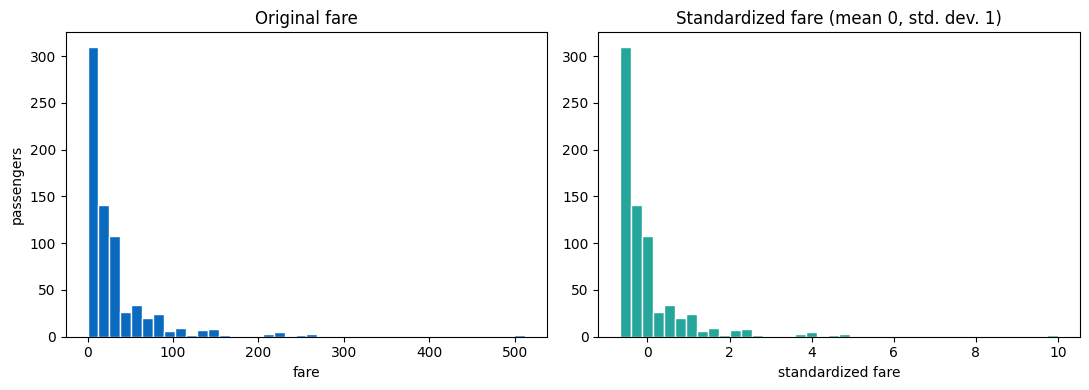

In [6]:
training_fare = X_train[["fare"]].dropna()
standardized_fare = StandardScaler().fit_transform(training_fare)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.hist(training_fare["fare"], bins=40, color="#0A6ABF", edgecolor="white")
ax1.set_title("Original fare")
ax1.set_xlabel("fare")
ax1.set_ylabel("passengers")

ax2.hist(standardized_fare, bins=40, color="#26A69A", edgecolor="white")
ax2.set_title("Standardized fare (mean 0, std. dev. 1)")
ax2.set_xlabel("standardized fare")

plt.tight_layout()
plt.show()


## 4. What does data leakage look like numerically?

A frequent mistake is to fit a scaler on the complete dataset before creating the train-test split. The numerical difference can appear small, but the second scaler has already incorporated information from the held-out observations.


In [7]:
correct_scaler = StandardScaler().fit(X_train[["fare"]].dropna())
leaked_scaler = StandardScaler().fit(X[["fare"]].dropna())

print(f"Mean learned from training data only: {correct_scaler.mean_[0]:.4f}")
print(f"Mean learned from train + test data:  {leaked_scaler.mean_[0]:.4f}")
print()
print("The second scaler has incorporated test-set statistics before evaluation.")


Mean learned from training data only: 31.8198
Mean learned from train + test data:  32.2042

The second scaler has incorporated test-set statistics before evaluation.


## 5. How can different feature types follow different paths?

Numerical columns receive median imputation and standardization. Categorical columns receive most-frequent imputation and one-hot encoding. `ColumnTransformer` keeps both paths inside one fitted object.


In [8]:
numeric_features = ["age", "fare"]
categorical_features = ["pclass", "sex", "embarked"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features),
])

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fe

## 6. How does the complete pipeline work?

The final `Pipeline` connects preprocessing to logistic regression. One call to `fit` learns every imputation value, scaling parameter, encoded category, and classifier coefficient from the training data only.


In [9]:
model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000)),
])

model.fit(X_train, y_train)

training_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print(f"Training accuracy: {training_accuracy:.3f}")
print(f"Test accuracy:     {test_accuracy:.3f}")


Training accuracy: 0.801
Test accuracy:     0.771


## 7. How does a pipeline protect cross-validation?

During cross-validation, scikit-learn refits the complete pipeline inside each fold. The validation fold therefore cannot influence the preprocessing parameters learned from that fold's training subset.


In [10]:
scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")

print(f"Accuracy by fold: {np.round(scores, 3)}")
print(f"Mean: {scores.mean():.3f} ± {scores.std():.3f}")


Accuracy by fold: [0.79  0.762 0.796 0.831 0.81 ]
Mean: 0.798 ± 0.023


## Next steps

A reliable production workflow should also preserve the fitted pipeline with the model, monitor feature distributions, and test behavior when new categories appear. Consult the [scikit-learn documentation on pipelines and composite estimators](https://scikit-learn.org/stable/modules/compose.html) for feature unions, model selection, and metadata routing.

This notebook accompanies the full article at [sigmoidal.ai](https://sigmoidal.ai/en/).
